# Nelson network: example

Integrates saved reduced-order models along a subset of the testing tracers of the full run, and reproduces its per-tracer figures. The example contains no training data, so no fitting is performed, and it requires no data outside this directory.

The positivity projection is enabled, since chemical abundances must remain non-negative.

In [1]:
import os
import sys
from types import SimpleNamespace

sys.path.insert(0, os.path.abspath("../../../"))

import numpy as np

from src import plots as P
from src.cluster import Cluster
from src.config import NSEC, combo_stem
from src.data import build_network, load_trajectories
from src.evaluate import evaluate
from src.hybrid import HybridConfig
from src.pipeline import case_config
from src.rom import EnsembleROM

%matplotlib inline

CASE = "nelson"
SWEEP_DIR = "sweep"
FIG_DIR = "figures"
POSITIVITY = True

## Load the example

`tracers.npz` holds the parameter trajectory of each included tracer, its global id, its position in the testing dataset of the full run, and the hydrodynamic time step. `feature_matrix_test.npy` holds the full-order trajectories of the same tracers, from which the initial states are taken.

The figure functions read only the network, the QoI indices, the time step and the global ids from the run context, so that subset is assembled here.

In [2]:
cfg = case_config(CASE, ".", n_workers=os.cpu_count() or 1)
net, qoi_indices = build_network(cfg)
qoi = [net.species[j] for j in qoi_indices]

with np.load("tracers.npz") as z:
    tracers = z["tracers"]
    global_ids = z["global_ids"]
    positions = z["source_positions"]
    dt_hydro = float(z["dt_hydro"])

t_foms, y_foms, x_eqs = load_trajectories("feature_matrix_test.npy", len(global_ids), len(net.species))
ctx = SimpleNamespace(net=net, qoi_indices=qoi_indices, dt_hydro=dt_hydro, test_indices=global_ids)

print(f"{len(global_ids)} tracers | {len(net.species)} species | qoi={qoi}")
print("positions: ", positions.tolist())
print("global ids:", global_ids.tolist())

10 tracers | 14 species | qoi=['CO', 'e-']
positions:  [0, 1, 2, 3, 4, 5, 6, 7, 600, 1391]
global ids: [12313, 0, 11886, 11067, 9860, 11219, 11487, 10774, 9722, 9377]


## Evaluate the models

Each included model is integrated along every included tracer. The table gives the relative L2-in-time error on each QoI, which equals the corresponding entry of the per-tracer tables of the full run.

In [3]:
MODELS = [(0.1, 1e-5)]   # (tau, eta) of each included model


def load_model(tau, eta):
    stem = combo_stem(tau, eta)
    cl = Cluster.load(f"{SWEEP_DIR}/cluster_{stem}.npz")
    return EnsembleROM.load(f"{SWEEP_DIR}/ensemble_{stem}.npz", cl, net).precompute_B_structure()


for tau, eta in MODELS:
    ens = load_model(tau, eta)
    res = evaluate(ens, tracers, x_eqs, t_foms, y_foms, qoi_indices, qoi, dt_hydro, cfg.replace(tau_split=tau, eta=eta, positivity=POSITIVITY), verbose=False)
    print(f"\n{combo_stem(tau, eta)}: {res['n_valid']}/{res['n_tracers']} complete, {len(ens.roms)} clusters, mean basis size {ens.mean_rank():.2f}")
    print(f"{'position':>9} {'global id':>9}  " + "  ".join(f"{q:>9}" for q in qoi))
    for row, k in enumerate(res["valid_idx"]):
        print(f"{positions[k]:>9} {global_ids[k]:>9}  " + "  ".join(f"{res['per_tracer']['l2-in-time'][q][row]:9.2e}" for q in qoi))

Loaded sweep/cluster_tol0.1_eta1e-5.npz  (k=883)



tol0.1_eta1e-5: 10/10 complete, 883 clusters, mean basis size 3.99
 position global id         CO         e-
        0     12313   3.02e-02   8.53e-04
        1         0   2.09e-03   5.29e-03
        2     11886   1.74e-01   3.09e-04
        3     11067   8.08e-03   1.83e-03
        4      9860   4.85e-03   3.02e-03
        5     11219   3.01e-03   5.69e-04
        6     11487   4.92e-02   1.66e-03
        7     10774   3.83e-02   1.89e-02
      600      9722   5.89e-03   2.42e-03
     1391      9377   6.19e-03   1.91e-03


## Figures

Every species along the chosen trajectory, grouped by how closely the reduced model follows it, with the cluster route shaded behind. The tracer is specified by its position in the testing dataset of the full run.

Loaded sweep/cluster_tol0.1_eta1e-5.npz  (k=883)


abundance figure: tracer 8 (global id 9722), tol0.1_eta1e-5


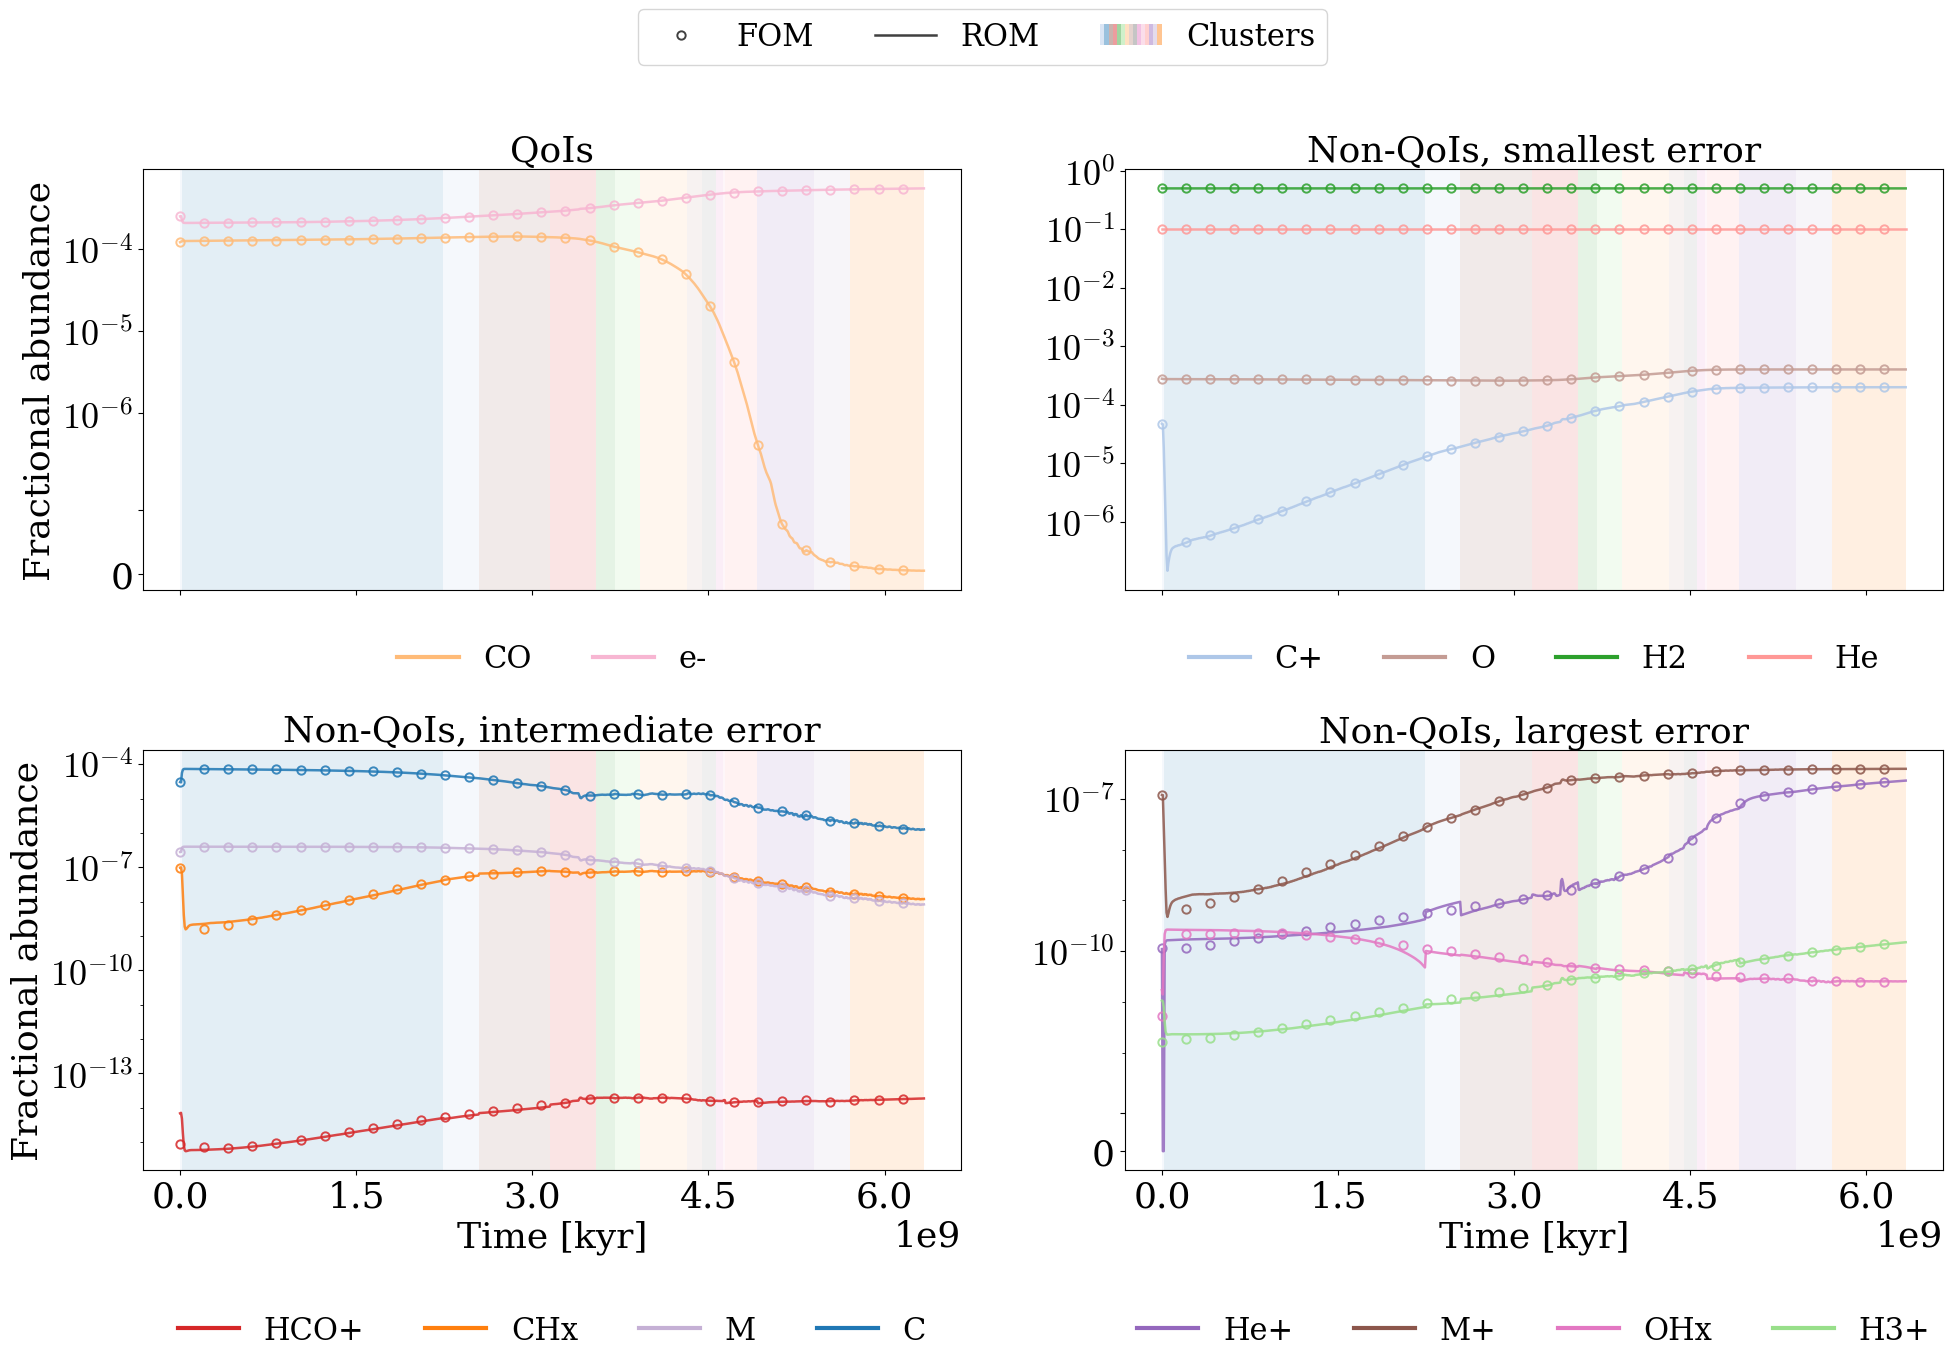

In [4]:
ABUND_TAU, ABUND_ETA = 0.1, 1e-5
ABUND_TRACER = 600              # position within the testing dataset of the full run

k = int(np.flatnonzero(positions == ABUND_TRACER)[0])
figa, info_a = P.tracer_figures(SWEEP_DIR, combo_stem(ABUND_TAU, ABUND_ETA), FIG_DIR, ctx, cfg.replace(tau_split=ABUND_TAU, eta=ABUND_ETA), None, tracers[k:k + 1], x_eqs[k:k + 1], t_foms[k:k + 1], y_foms[k:k + 1], 0, global_ids=global_ids, position=k)

The hybrid solve compared against the clustered ROM alone. Where the state entering a new cluster is poorly represented by that cluster's basis, the solve rewinds and recomputes the window at full order. The rewind threshold is the square root of eta, as in the full run.

Loaded sweep/cluster_tol0.1_eta1e-5.npz  (k=883)


hybrid figure: tracer 9, tol0.1_eta1e-5


wrote figures/hybrid_comparison.pdf
HybridConfig(lookback=10, n_fom=11, thresh=0.00316228, positivity=True, force_fom=False)
  rewinds 1, FOM intervals 11/803 (1.4%)
  positivity: entry 1, endpoint 2
  cluster switches 13
  cost: 1 FOM solve(s) 0.01s, 802 ROM solve(s) 1.70s (0 discarded) -- 0.4% of time at full order
  triggers: interval 614 at 0.00405
  FOM intervals 604-614 = 151-154 s


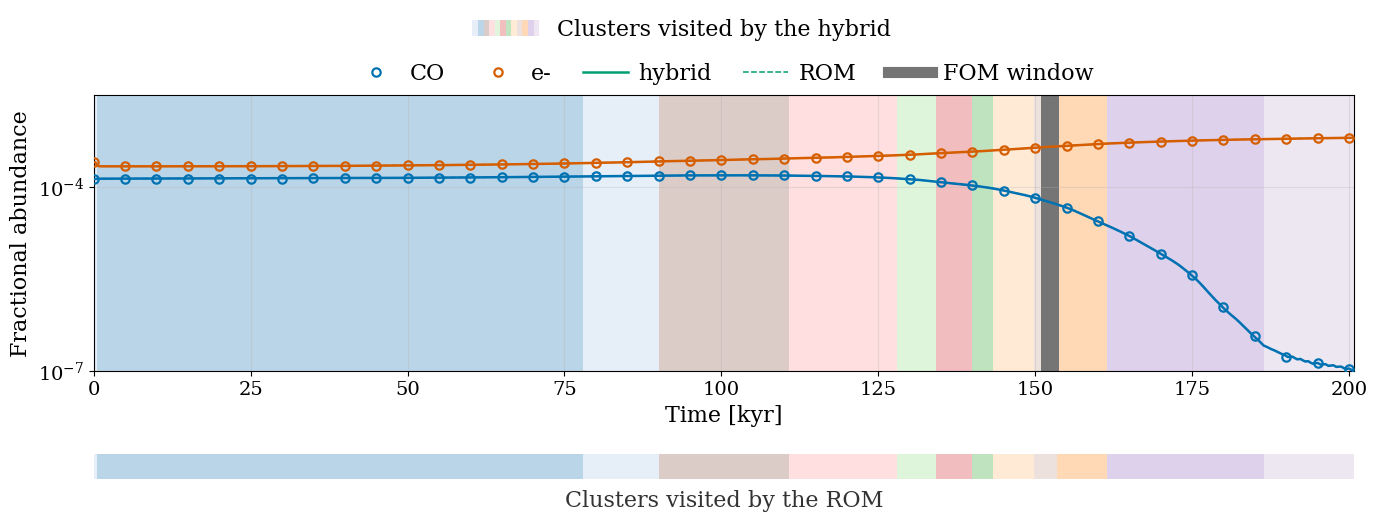

In [5]:
HYB_TAU, HYB_ETA = 0.1, 1e-5
HYB_TRACER = 1391              # position within the testing dataset of the full run

k = int(np.flatnonzero(positions == HYB_TRACER)[0])
figh, res_h = P.hybrid_figures(SWEEP_DIR, combo_stem(HYB_TAU, HYB_ETA), FIG_DIR, ctx, cfg.replace(tau_split=HYB_TAU, eta=HYB_ETA), tracers[k:k + 1], x_eqs[k:k + 1], t_foms[k:k + 1], y_foms[k:k + 1], 0, hybrid=HybridConfig(lookback=10, n_fom=11, thresh=np.sqrt(HYB_ETA)), time_scale=NSEC * 1e3, time_label="Time [kyr]", position=k)

print(res_h.summary(time_scale=NSEC * 1e3))